<hr/>

# EN.520.637 Foundations of Reinforcement Learning

<hr/>

<h1><font color="darkblue">Lab 4: Multi-armed Bandits, Monte Carlo Control & TD-Methods (110 points)  </font></h1>





##  Content
1. Multi-armed Bandits
2. Monte Carlo Methods
3. TD-Methods: SARSA, Q-learning

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Problem 1.  Greedy and $\epsilon$-greedy algorithm (30 points)

Taken from [P 21, Ch 2.3, Sutton&Barton]
#### Define a 10-armed bandit problem in which the action values $q_*(a)$, $a = 1,...,10$, are samples from a standard normal distribution, i.e. Gaussian distribution with mean $= 0$ and variance $ = 1$. Then, when selected $A_t$ at time step $t$, the actual reward, $R_t$ is selected from a Gaussian distribution with mean = $q_*(A_t)$ and variance = 1.

---

## 1.1 Epsilon greedy (15 points)

We will see the average performance of epsilon greedy algorithms on this problem. To this matter, you will:
- given the bandits, use your algorithm for 1000 time steps.
- Repeat for 2000 independent trials.

1. Implement a function/functions that runs 2000 independent experiments. An experiment is defined as 1. an initialization of the bandit reward distributions, and 2. running your algorithm for 1000 time steps, using an $\epsilon$-greedy algorithm. Your function/functions should take $\epsilon$ as one of the inputs and output:
<br>   (a) average reward at each time step
<br>   (b) percentage of optimal action at each time step. (optimal action is defined by $a^* = arg\underset{a}max           \, q^*(a)$ )
3. Call your function/functions to generate the average reward and percentage of optimal action at each time step with:
<br>   (a) Greedy-algorithm
<br>   (b) $\epsilon$-greedy algorithm, $\epsilon=0.01$
<br>   (c) $\epsilon$-greedy algorithm, $\epsilon=0.1$.
4. Plot the average reward and percentage of optimal action of those three cases and compare with [P 23 Fig 2.2 Sutton].

### 1.1.1 (5 points)

In [2]:
def run_one_experiment(epsilon, n_steps=1000, n_arms=10, rng=None):
    q_star = rng.normal(0, 1, n_arms)    # true value
    best_a = np.argmax(q_star)

    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)

    rewards = np.zeros(n_steps)
    is_opt  = np.zeros(n_steps)

    for t in range(n_steps):
        if rng.random() < epsilon:
            a = rng.integers(0, n_arms)       # explore
        else:
            a = np.argmax(Q)                  # exploit

        r = rng.normal(q_star[a], 1.0)        # reward ~ N(q*(a), 1)

        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]

        rewards[t] = r
        is_opt[t]  = 1.0 if a == best_a else 0.0

    return rewards, is_opt


def run_all(epsilon, n_runs=2000, n_steps=1000, seed=0):
    rng = np.random.default_rng(seed)
    avg_reward = np.zeros(n_steps)
    opt_pct    = np.zeros(n_steps)
    for _ in range(n_runs):
        r, o = run_one_experiment(epsilon, n_steps=n_steps, rng=rng)
        avg_reward += r
        opt_pct    += o
    return avg_reward / n_runs, opt_pct / n_runs

### 1.1.2 (5 points)

In [3]:
avg_r_0,    opt_0    = run_all(epsilon=0.0,  seed=0)
avg_r_001,  opt_001  = run_all(epsilon=0.01, seed=1)
avg_r_01,   opt_01   = run_all(epsilon=0.1,  seed=2)
print("done")

done


### 1.1.3 (5 points)

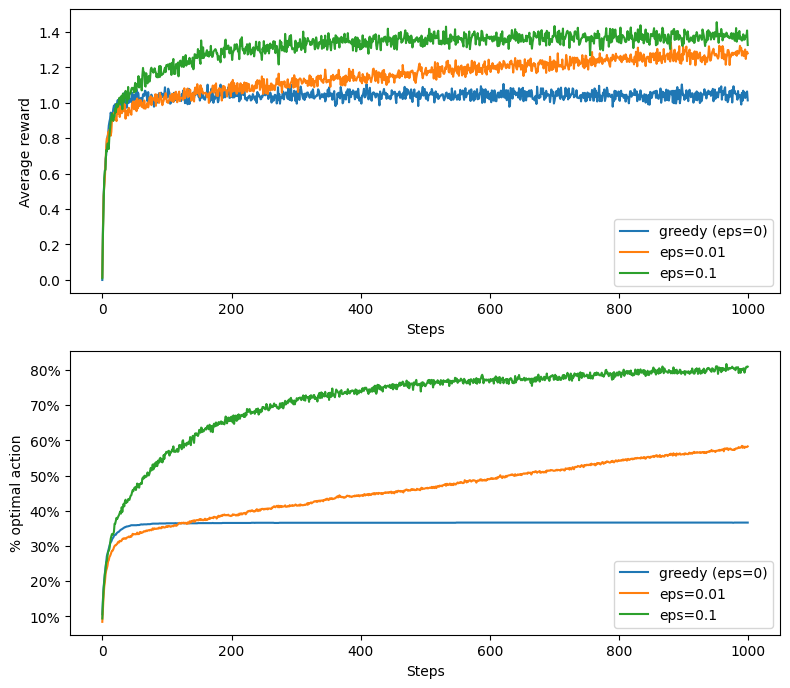

In [4]:
# 1.1.3  画 average reward 和 %optimal action
fig, ax = plt.subplots(2, 1, figsize=(8, 7))

ax[0].plot(avg_r_0,   label='greedy (eps=0)')
ax[0].plot(avg_r_001, label='eps=0.01')
ax[0].plot(avg_r_01,  label='eps=0.1')
ax[0].set_xlabel('Steps')
ax[0].set_ylabel('Average reward')
ax[0].legend()

ax[1].plot(opt_0 * 100,   label='greedy (eps=0)')
ax[1].plot(opt_001 * 100, label='eps=0.01')
ax[1].plot(opt_01 * 100,  label='eps=0.1')
ax[1].set_xlabel('Steps')
ax[1].set_ylabel('% optimal action')
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax[1].legend()

plt.tight_layout()
plt.show()

---
## 1.2  UCB Action Selection (15 points)

1. Implement a function/functions that runs 2000 instances of this experiment, each experiment for 1000 time steps, using UCB Action Selection algorithm. Your function/functions should take $c$ as one of the inputs and output:
<br>   - average reward at each time step.
2. Call your function/functions to generate the average reward at each time step with:
<br>   - UCB Action Selection algorithm, $c = 2$.
3. Plot the average reward of 2.2 and 1.2c, then compare with [P 28 Fig 2.4 Sutton].

### 1.2.1 (5 points)

In [5]:
# A_t = argmax [ Q(a) + c * sqrt(ln t / N(a)) ]

def run_one_ucb(c, n_steps=1000, n_arms=10, rng=None):
    q_star = rng.normal(0, 1, n_arms)
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)

    rewards = np.zeros(n_steps)

    for t in range(n_steps):
        # choose every arms once first
        if np.any(N == 0):
            a = np.argmin(N)
        else:
            ucb = Q + c * np.sqrt(np.log(t + 1) / N)
            a = np.argmax(ucb)

        r = rng.normal(q_star[a], 1.0)
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]
        rewards[t] = r

    return rewards


def run_all_ucb(c, n_runs=2000, n_steps=1000, seed=0):
    rng = np.random.default_rng(seed)
    avg_reward = np.zeros(n_steps)
    for _ in range(n_runs):
        avg_reward += run_one_ucb(c, n_steps=n_steps, rng=rng)
    return avg_reward / n_runs

### 1.2.2 (5 points)

In [6]:
avg_r_ucb = run_all_ucb(c=2, seed=3)
print("done")

done


### 1.2.3 (5 points)

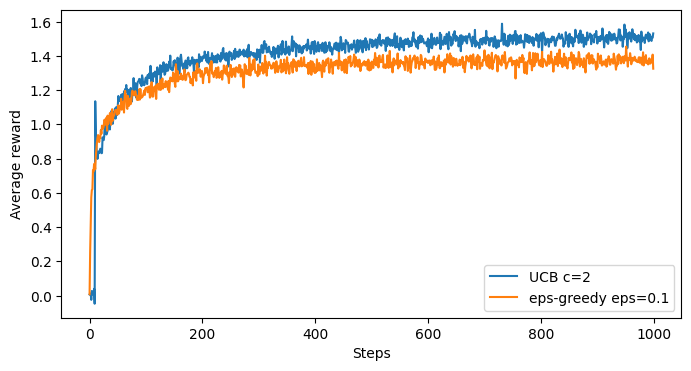

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(avg_r_ucb, label='UCB c=2')
plt.plot(avg_r_01,  label='eps-greedy eps=0.1')
plt.xlabel('Steps')
plt.ylabel('Average reward')
plt.legend()
plt.show()

# Problem 2. Monte Carlo Methods  (CartPole-v1 environment) (20 points)

## 2.1 CartPole Introduction

We now apply Monte Carlo Method for the CartPole problem. See:
[CartPole documentation](https://gymnasium.farama.org/environments/classic_control/cart_pole/)


1. A pole is attached by an un-actuated joint to a cart, which moves along a frictionless track.

0. The system is controlled by applying a force of +1 or -1 to the cart.

0. The pendulum starts upright, and the goal is to prevent it from falling over.

0. A reward of +1 is provided for every timestep that the pole remains upright.

0. The episode ends when the pole is more than 15 degrees from vertical, or the cart moves more than 2.4 units from the center.

0. For more info (See [SOURCE ON GITHUB](https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py)).



The following examples show the basic usage of this testing environment:



### 2.1.1 Episode initialization and Initial Value

In [8]:
import gymnasium as gym

In [9]:
env = gym.make('CartPole-v1')
observation, info = env.reset()

print("Inital observation is {}".format(observation))

print("\nThis means the cart current position is {}".format(observation[0]), end = '')
print(" with velocity {},".format(observation[1]))

print("and the pole current angular position is {}".format(observation[2]), end = '')
print(" with angular velocity {},".format(observation[3]))

Inital observation is [ 0.01395066 -0.00134711 -0.01264623  0.02080259]

This means the cart current position is 0.013950662687420845 with velocity -0.0013471062993630767,
and the pole current angular position is -0.01264623086899519 with angular velocity 0.020802589133381844,


### 2.1.2 Take actions


Use env.step(action) to take an action

action is an integer from 0 to 1

0: "Left"; 1: "Right"

In [10]:
print("Current observation is {}".format(observation))

action = 0
observation, reward, terminated, truncated, info = env.step(action)
done = terminated or truncated

print("\nNew observation is {}".format(observation))
print("Step reward is {}".format(reward))
print("Did episode just end? -{}".format(done))

Current observation is [ 0.01395066 -0.00134711 -0.01264623  0.02080259]

New observation is [ 0.01392372 -0.19628544 -0.01223018  0.3094688 ]
Step reward is 1.0
Did episode just end? -False


### 2.1.3 Simulate multiple episodes

(You may uncomment those lines to see an animation. However, it will not work for JupyterHub since the animation requires GL instead of webGL. If you have Jupyter notebook localy on your computer, this version of code will work through a virtual frame.)

In [11]:
env = gym.make('CartPole-v1')
observation, info = env.reset()
total_reward = 0
ep_num = 0

for _ in range(1000):
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    total_reward += reward

    if done:
        observation, info = env.reset()
        ep_num += 1

print("Average reward per episode is {}".format(total_reward/ep_num))
env.close()

Average reward per episode is 20.833333333333332


### 2.1.4 States Discretization

The class DiscreteObs() discretizes the observation space into discrete state space, based on numpy.digitize (Please read its description in https://numpy.org/doc/stable/reference/generated/numpy.digitize.html)

Discretization of observation space is necessary for tabular methods. You can use DiscreteObs() or any other library for discretizing the observation space.

In [12]:
class DiscretObs():

    def __init__(self, bins_list):
        self._bins_list = bins_list

        self._bins_num = len(bins_list)
        self._state_num_list = [len(bins)+1 for bins in bins_list]
        self._state_num_total = np.prod(self._state_num_list)

    def get_state_num_total(self):

        return self._state_num_total

    def obs2state(self, obs):

        if not len(obs)==self._bins_num:
            raise ValueError("observation must have length {}".format(self._bins_num))
        else:
            return [np.digitize(obs[i], bins=self._bins_list[i]) for i in range(self._bins_num)]

    def obs2idx(self, obs):

        state = self.obs2state(obs)

        return self.state2idx(state)

    def state2idx(self, state):

        idx = 0
        for i in range(self._bins_num-1,-1,-1):
            idx = idx*self._state_num_list[i]+state[i]

        return idx

    def idx2state(self, idx):

        state = [None]*self._bins_num
        state_num_cumul = np.cumprod(self._state_num_list)
        for i in range(self._bins_num-1,0,-1):
            state[i] = idx/state_num_cumul[i-1]
            idx -=state[i]*state_num_cumul[i-1]
        state[0] = idx%state_num_cumul[0]

        return state

bins_pos = np.linspace(-2.4,2.4,40)
bins_d_pos = np.linspace(-3,3,5)
bins_ang = np.linspace(-0.2618,0.2618,40)
bins_d_ang = np.linspace(-0.3,0.3,5)

dobs = DiscretObs([bins_pos,bins_d_pos,bins_ang,bins_d_ang])
observation, info = env.reset()

state = dobs.obs2state(observation)
idx = dobs.obs2idx(observation)

print("Current position of the cart is {:.4f}\n".format(observation[0]))
print("Current velocity of the cart is {:.4f}\n".format(observation[1]))
print("Current angular position of the pole is {:.4f} rad\n".format(observation[2]))
print("Current angular velocity of the pole is {:.4f} rad\n".format(observation[3]))

print("which are mapped to state {}, with corresponding index {}".format(state,idx))

Current position of the cart is 0.0455

Current velocity of the cart is -0.0367

Current angular position of the pole is 0.0127 rad

Current angular velocity of the pole is 0.0120 rad

which are mapped to state [np.int64(20), np.int64(2), np.int64(21), np.int64(3)], with corresponding index 35526


## 2.2 On-policy first-visit MC control
### Task 2. [Coding, 20 points]

1. Implement "On-policy first-visit MC control" algorithum in [Ch 5.4 Sutton] to choose optimal actions
2. Simulate this algorithm for 40000 episodes.
3. Plot the reward for each episode

### 2.1 Implementation (15 points)

In [13]:
# 2.2  On-policy first-visit MC control

def get_action(current_state, Q, epsilon, n_actions=2):
    if np.random.rand() < epsilon:
        return np.random.randint(n_actions)
    return int(np.argmax(Q[tuple(current_state)]))


def update_Q(Q, N, state_list, action_list, reward_list, gamma):
    # first-visit MC
    G = 0.0
    visited = set()
    first_visit = [False] * len(state_list)
    for i, (s, a) in enumerate(zip(state_list, action_list)):
        key = (tuple(s), a)
        if key not in visited:
            visited.add(key)
            first_visit[i] = True

    for t in range(len(state_list) - 1, -1, -1):
        G = gamma * G + reward_list[t]
        if first_visit[t]:
            s = tuple(state_list[t])
            a = action_list[t]
            idx = s + (a,)
            N[idx] += 1
            Q[idx] += (G - Q[idx]) / N[idx]
    return Q, N


# ---- setup ----
bins_pos   = np.linspace(-2.4, 2.4, 40)
bins_d_pos = np.linspace(-3, 3, 5)
bins_ang   = np.linspace(-0.2618, 0.2618, 40)
bins_d_ang = np.linspace(-0.3, 0.3, 5)
dobs = DiscretObs([bins_pos, bins_d_pos, bins_ang, bins_d_ang])

env = gym.make('CartPole-v1')
n_actions = 2

Q_shape = tuple(dobs._state_num_list) + (n_actions,)
Q = np.zeros(Q_shape)
N = np.zeros(Q_shape)

n_episodes = 40000
epsilon_start = 0.3
epsilon_decay_rate = 0.9999
epsilon = epsilon_start
gamma = 1.0

rewards_per_ep = np.zeros(n_episodes)

for ep in range(n_episodes):
    obs, info = env.reset()

    state_list, action_list, reward_list = [], [], []
    done = False
    ep_reward = 0

    while not done:
        current_state = dobs.obs2state(obs)
        action = get_action(current_state, Q, epsilon, n_actions)

        obs, r, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        state_list.append(current_state)
        action_list.append(action)
        reward_list.append(r)
        ep_reward += r

    Q, N = update_Q(Q, N, state_list, action_list, reward_list, gamma)
    rewards_per_ep[ep] = ep_reward


    if (ep + 1) % 2000 == 0:
        start = ep - 999 if ep >= 999 else 0
        print(f"ep {ep+1}, recent mean reward = {rewards_per_ep[start:ep+1].mean():.1f}, eps={epsilon:.3f}")

env.close()

ep 2000, recent mean reward = 177.3, eps=0.300
ep 4000, recent mean reward = 244.5, eps=0.300
ep 6000, recent mean reward = 278.5, eps=0.300
ep 8000, recent mean reward = 296.8, eps=0.300
ep 10000, recent mean reward = 306.6, eps=0.300
ep 12000, recent mean reward = 311.0, eps=0.300
ep 14000, recent mean reward = 318.4, eps=0.300
ep 16000, recent mean reward = 329.8, eps=0.300
ep 18000, recent mean reward = 334.7, eps=0.300
ep 20000, recent mean reward = 343.2, eps=0.300
ep 22000, recent mean reward = 340.7, eps=0.300
ep 24000, recent mean reward = 343.4, eps=0.300
ep 26000, recent mean reward = 351.6, eps=0.300
ep 28000, recent mean reward = 352.1, eps=0.300
ep 30000, recent mean reward = 354.5, eps=0.300
ep 32000, recent mean reward = 356.1, eps=0.300
ep 34000, recent mean reward = 346.3, eps=0.300
ep 36000, recent mean reward = 368.9, eps=0.300
ep 38000, recent mean reward = 359.3, eps=0.300
ep 40000, recent mean reward = 360.5, eps=0.300


### 2.2 Plot your results (5 points)

Since results are noisy, you can try:
- Plotting your un-filtered results
- using window-averaging to smooth out your results (code snippet below)

Plot both curves in the same figure


In [14]:
# Window averaging to smooth out plots

def moving_average(arr, window_size):
    window = np.ones(window_size) / window_size
    return np.convolve(arr, window, mode='valid')

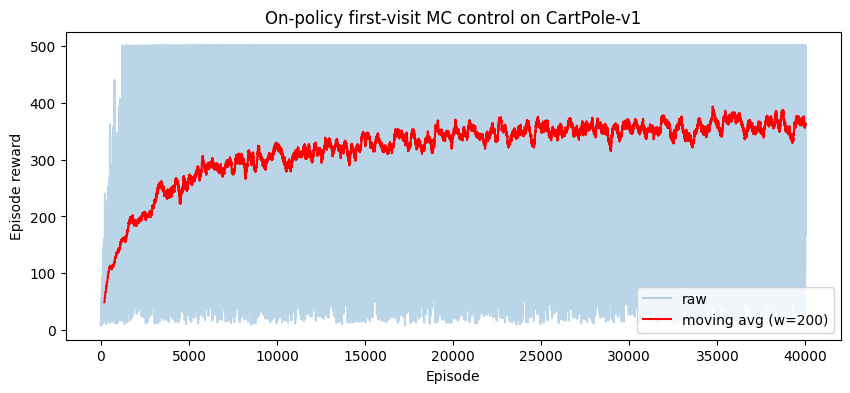

In [15]:
window = 200
smoothed = moving_average(rewards_per_ep, window)

plt.figure(figsize=(10, 4))
plt.plot(rewards_per_ep, alpha=0.3, label='raw')
plt.plot(np.arange(window - 1, len(rewards_per_ep)), smoothed, color='red', label=f'moving avg (w={window})')
plt.xlabel('Episode')
plt.ylabel('Episode reward')
plt.title('On-policy first-visit MC control on CartPole-v1')
plt.legend()
plt.show()

# Problem 3: TD-Methods (SARSA & Q-learning) (50 points)

## 3.1 Cliff walk enviornment

### 3.1.1 Intro to Cliff walk

In this section, we use SARSA and Q-learning algorithm to solve to a cliff walk problem. ( See Sutton&Barto Example 6.6 )

The grid is shown below, the black tiles represents wall/obstacles, the white tiles are the non-terminal tiles, and the tile with "s" is the starting point of every episoid, the tile with "G" is the goal point.

The agent start at "s" tile. At every step, the agent can choose one of the four actions:"up","right","down","left", moving to the next tile in that direction.

$\cdot$ If the next tile is wall/obstacle, the agent does not move and receive -1 reward;

$\cdot$ If the next tile is a non-terminal tile, the agent move to that tile and receive 0 reward;

$\cdot$ If the next tile is the goal tile, the episoid is finished and the agent receive 100 reward (set to be 100 to accelarate the training).

$\cdot$ If the next tile is the cliff, the episoid is finished and the agent receive -100 reward ;

In [16]:
# The environment
import matplotlib.pyplot as plt
import numpy as np


class CliffWalk:

    def __init__(self, reward_wall=-1):
        # initialize grid with 2d numpy array
        # >0: goal
        # -1: wall/obstacles
        # 0: non-terminal
        self._grid = np.array(
            [ [0, 0, 0, 0, 0, 0, 0, 0],
             [0, 0, 0, 0, 0, 0, 0, 0],
             [0, 0, 0, 0, 0, 0, 0, 0],
             [0, -100, -100, -100, -100, -100, -100, 100]
             ])
        # wall around the grid, padding grid with -1
        self._grid_padded = np.pad(self._grid, pad_width=1, mode='constant', constant_values=-1)
        self._reward_wall = reward_wall

        # set start state
        self._start_state = (3, 0)
        self._random_start = False

        # store position of goal states and non-terminal states
        idx_goal_state_y, idx_goal_state_x = np.nonzero(self._grid > 0)
        self._goal_states = [(idx_goal_state_y[i], idx_goal_state_x[i]) for i in range(len(idx_goal_state_x))]

        idx_non_term_y, idx_non_term_x = np.nonzero(self._grid == 0)
        self._non_term_states = [(idx_non_term_y[i], idx_non_term_x[i]) for i in range(len(idx_non_term_x))]

        # store the current state in the padded grid
        self._state_padded = (self._start_state[0] + 1, self._start_state[1] + 1)

    def get_state_num(self):
        # get the number of states (total_state_number) in the grid, note: the wall/obstacles inside the grid are
        # counted as state as well
        return np.prod(np.shape(self._grid))

    def get_state_grid(self):

        state_grid = np.multiply(np.reshape(np.arange(self.get_state_num()), self._grid.shape), self._grid >= 0) - (
                self._grid == -1) #- (self._grid == -100)

        return state_grid, np.pad(state_grid, pad_width=1, mode='constant', constant_values=-1)

    def get_current_state(self):
        # get the current state as an integer from 0 to total_state_number-1
        y, x = self._state_padded
        return (y - 1) * self._grid.shape[1] + (x - 1)

    def int_to_state(self, int_obs):
        # convert an integer from 0 to total_state_number-1 to the position on the non-padded grid
        x = int_obs % self._grid.shape[1]
        y = int_obs // self._grid.shape[1]
        return y, x

    def reset(self):
        # reset the gridworld
        if self._random_start:
            # randomly start at a non-terminal state
            idx_start = np.random.randint(len(self._non_term_states))
            start_state = self._non_term_states[idx_start]
            self._state_padded = (start_state[0] + 1, start_state[1] + 1)
        else:
            # start at the designated start_state
            self._state_padded = (self._start_state[0] + 1, self._start_state[1] + 1)

    def step(self, action):
        # take one step according to the action
        # input: action (integer between 0 and 3)
        # output: reward           reward of this action
        #         terminated       1 if reaching the terminal state, 0 otherwise
        #         next_state       next state after this action, integer from 0 to total_state_number-1)
        y, x = self._state_padded

        if action == 0:  # up
            new_state_padded = (y - 1, x)
        elif action == 1:  # right
            new_state_padded = (y, x + 1)
        elif action == 2:  # down
            new_state_padded = (y + 1, x)
        elif action == 3:  # left
            new_state_padded = (y, x - 1)
        else:
            raise ValueError("Invalid action: {} is not 0, 1, 2, or 3.".format(action))

        new_y, new_x = new_state_padded
        if self._grid_padded[new_y, new_x] == -1:  # wall/obstacle
            reward = self._reward_wall
            new_state_padded = (y, x)
        elif self._grid_padded[new_y, new_x] == 0:  # non-terminal cell
            reward = -1.
        else:  # a goal
            reward = self._grid_padded[new_y, new_x]
            self.reset()
            terminated = 1
            return reward, terminated, self.get_current_state()

        terminated = 0
        self._state_padded = new_state_padded
        return reward, terminated, self.get_current_state()


    def plot_grid(self, plot_title=None):
        # plot the grid
        plt.figure(figsize=(5, 5))
        plt.imshow((self._grid_padded == -1) + (self._grid_padded == -100) * 0.5, cmap='Greys', vmin=0, vmax=1)
        ax = plt.gca()
        ax.grid(0)
        plt.xticks([])
        plt.yticks([])

        if plot_title:
            plt.title(plot_title)

        plt.text(
            self._start_state[1] + 1, self._start_state[0] + 1,
            r"$\mathbf{S}$", ha='center', va='center')
        for goal_state in self._goal_states:
            plt.text(
                goal_state[1] + 1, goal_state[0] + 1,
                r"$\mathbf{G}$", ha='center', va='center')
        h, w = self._grid_padded.shape
        for y in range(h - 1):
            plt.plot([-0.5, w - 0.5], [y + 0.5, y + 0.5], '-k', lw=2)
        for x in range(w - 1):
            if x in np.arange(2,7):
                plt.plot([x + 0.5, x + 0.5], [-0.5, h - 2.5], '-k', lw=2)
                continue
            plt.plot([x + 0.5, x + 0.5], [-0.5, h - 0.5], '-k', lw=2)
        plt.text(4.5, 4,r"T h e   C l i f f", ha='center', va='center')

    def plot_state_values(self, state_values, value_format="{:.1f}",plot_title=None):
        # plot the state values
        # input: state_values     (total_state_number, )-numpy array, state value function
        #        plot_title       str, title of the plot
        plt.figure(figsize=(5, 5))
        plt.imshow((self._grid_padded == -1) + (self._grid_padded == -100) * 0.5, cmap='Greys', vmin=0, vmax=1)
        ax = plt.gca()
        ax.grid(0)
        plt.xticks([])
        plt.yticks([])

        if plot_title:
            plt.title(plot_title)

        for (int_obs, state_value) in enumerate(state_values):
            y, x = self.int_to_state(int_obs)
            if (y, x) in self._non_term_states:
                plt.text(x + 1, y + 1, value_format.format(state_value), ha='center', va='center')
        for goal_state in self._goal_states:
            plt.text(
                goal_state[1] + 1, goal_state[0] + 1,
                r"$\mathbf{G}$", ha='center', va='center')
        h, w = self._grid_padded.shape
        for y in range(h - 1):
            plt.plot([-0.5, w - 0.5], [y + 0.5, y + 0.5], '-k', lw=2)
        for x in range(w - 1):
            if x in np.arange(2,7):
                plt.plot([x + 0.5, x + 0.5], [-0.5, h - 2.5], '-k', lw=2)
                continue
            plt.plot([x + 0.5, x + 0.5], [-0.5, h - 0.5], '-k', lw=2)

    def plot_policy(self, policy, plot_title=None):
        # plot a deterministic policy
        # input: policy           (total_state_number, )-numpy array, contains action as integer from 0 to 3
        #        plot_title       str, title of the plot
        action_names = [r"$\uparrow$", r"$\rightarrow$", r"$\downarrow$", r"$\leftarrow$"]
        plt.figure(figsize=(5, 5))
        plt.imshow((self._grid_padded == -1) + (self._grid_padded == -100) * 0.5, cmap='Greys', vmin=0, vmax=1)
        ax = plt.gca()
        ax.grid(0)
        plt.xticks([])
        plt.yticks([])

        for goal_state in self._goal_states:
            plt.text(
                goal_state[1] + 1, goal_state[0] + 1,
                r"$\mathbf{G}$", ha='center', va='center')

        if plot_title:
            plt.title(plot_title)

        for (int_obs, action) in enumerate(policy):
            y, x = self.int_to_state(int_obs)
            if (y, x) in self._non_term_states:
                action_arrow = action_names[action]
                plt.text(x + 1, y + 1, action_arrow, ha='center', va='center')


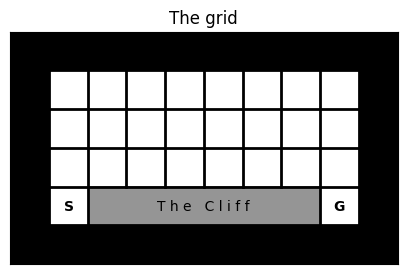

In [17]:
gw = CliffWalk()
gw.plot_grid(plot_title='The grid')

### 3.1.2 States and state values
Excluding the wall around the grid, there are 32 tiles (INCLUDING obstacles inside the grid), and they correspond to 32 states (obstacles and goal are non-reachable states).

We use numbers from 0 to 24 to represent these states (see gridworld.py for the coversion between integer and tile position). The correspondance are as shown below:

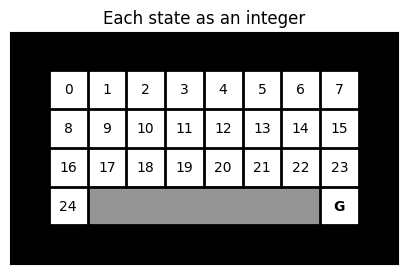

In [18]:
gw.plot_state_values(np.arange(25),value_format="{:d}",plot_title='Each state as an integer')

### 3.1.3 Taking actions
Use GridWorld.step(action) to take an action, and use GridWorld.reset() to restart an episoid

action is an integer from 0 to 3

0: "Up"; 1: "Right"; 2: "Down"; 3: "Left"

In [19]:
gw.reset()

current_state = gw.get_current_state()
tile_pos = gw.int_to_state(current_state)

print("The current state is {}, which corresponds to tile position {}\n".format(current_state,tile_pos))

action = np.random.randint(4)
reward, terminated, next_state = gw.step(action)
tile_pos = gw.int_to_state(next_state)

print("Take action {}, get reward {}, move to state {}".format(action,reward,next_state))
print("Now the current state is {}, which corresponds to tile position {}\n".format(next_state,tile_pos))

gw.reset()
current_state = gw.get_current_state()
tile_pos = gw.int_to_state(current_state)
print("Reset episode")
print("Now the current state is {}, which corresponds to tile position {}".format(current_state,tile_pos))



The current state is 24, which corresponds to tile position (3, 0)

Take action 3, get reward -1, move to state 24
Now the current state is 24, which corresponds to tile position (3, 0)

Reset episode
Now the current state is 24, which corresponds to tile position (3, 0)


### 3.1.4. Plotting Deterministic Policies
A deterministic policy is a function from state to action, which can be represented by a (32,)-numpy array whose entries are all integers in (0-3)

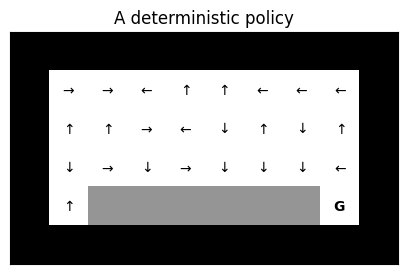

In [20]:
gw.plot_policy(np.random.randint(4,size=(32,)),plot_title='A deterministic policy')

## 3.2 SARSA & Q_learning

You will now implement Sarsa and Q learning

In [21]:

def update_Q(Q, current_idx, next_idx, current_action, next_action, alpha, R, gamma):
    td_target = R + gamma * Q[next_idx, next_action]
    td_error  = td_target - Q[current_idx, current_action]
    Q[current_idx, current_action] += alpha * td_error
    return Q


def get_action(current_idx, Q, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(Q.shape[1])
    return int(np.argmax(Q[current_idx]))

### [Task] 3.2.1 SARSA [Coding: 10 points]

* Implement SARSA (See Sutton&Barto Section 6.4) on this example for 5000 episodes to learn the optimal policy.
* Plot the greedy policy of the learned Q-function using gw.plot_policy()

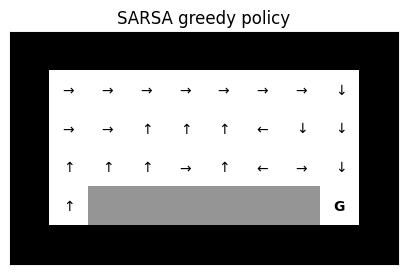

In [22]:
## SARSA on CliffWalk
np.random.seed(0)
Q_sarsa = np.zeros((32, 4))

gw = CliffWalk()
max_ep = 5000
total_reward_sarsa = np.zeros(max_ep)

epsilon = 0.1
alpha = 0.5
gamma = 0.9

for ep in range(max_ep):
    gw.reset()
    current_state = gw.get_current_state()
    current_action = get_action(current_state, Q_sarsa, epsilon)

    terminated = False
    while not terminated:
        reward, terminated, next_state = gw.step(current_action)
        if not reward == 100:
            total_reward_sarsa[ep] += reward

        next_action = get_action(next_state, Q_sarsa, epsilon)
        Q_sarsa = update_Q(Q_sarsa, current_state, next_state,
                           current_action, next_action, alpha, reward, gamma)

        current_state = next_state
        current_action = next_action

policy_sarsa = np.argmax(Q_sarsa, axis=1)
gw.plot_policy(policy_sarsa[:25], plot_title='SARSA greedy policy')

### [Task] 3.2.2 Q-learning [Coding: 10 points]
* Implement Q_learning algorithm (See Sutton&Barto Section 6.5) on this example for 5000 episodes to learn the optimal policy.
* Plot the greedy policy of the learned Q-function using gw.plot_policy()



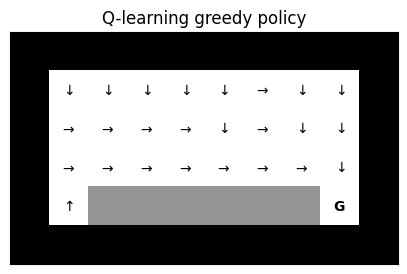

In [23]:
## Q-learning on CliffWalk
np.random.seed(0)
Q_ql = np.zeros((32, 4))

gw = CliffWalk()
max_ep = 5000
total_reward_qlearning = np.zeros(max_ep)

epsilon = 0.1
alpha = 0.5
gamma = 0.9

for ep in range(max_ep):
    gw.reset()
    current_state = gw.get_current_state()

    terminated = False
    while not terminated:
        current_action = get_action(current_state, Q_ql, epsilon)
        reward, terminated, next_state = gw.step(current_action)
        if not reward == 100:
            total_reward_qlearning[ep] += reward

        max_action = int(np.argmax(Q_ql[next_state]))
        Q_ql = update_Q(Q_ql, current_state, next_state,
                        current_action, max_action, alpha, reward, gamma)

        current_state = next_state

policy_ql = np.argmax(Q_ql, axis=1)
gw.plot_policy(policy_ql[:25], plot_title='Q-learning greedy policy')

### [Task 3.2.3] Comparison [Coding/Question 10 points]
* Plot the total rewards during one episode v.s. number of episodes trained for both SARSA and Q-Learning.

* Compare your plot to the one in [Sutton & Barto Figure 6.4].

* Which algorithm obtains bette performance? Provide some intuition on why this is the case.

(Optional)You may  

1. Smooth your curve by taking the average of total rewards over successive 50 episodes
2. Avoid adding the artificial "+100" goal reward to the total reward to match you figure with the book (Although we need to used goal reward when update the Q-function )



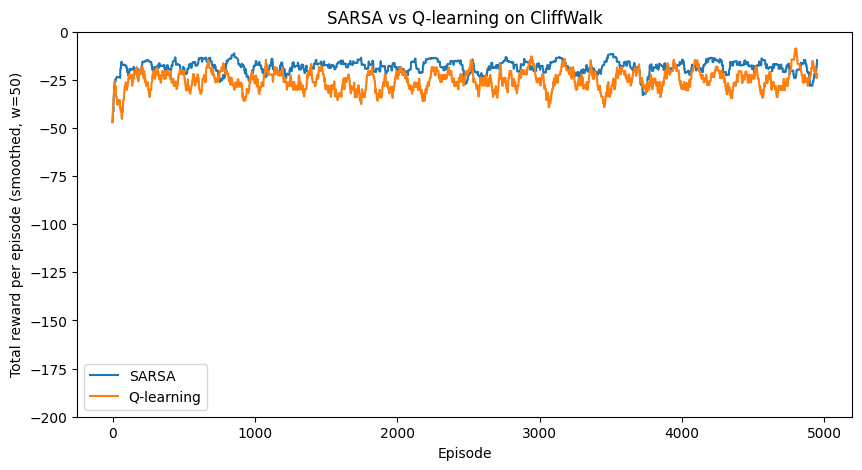

In [24]:
# comparsion of reward curves
w = 50
sarsa_smooth = moving_average(total_reward_sarsa, w)
ql_smooth    = moving_average(total_reward_qlearning, w)

plt.figure(figsize=(10, 5))
plt.plot(sarsa_smooth, label='SARSA')
plt.plot(ql_smooth,    label='Q-learning')
plt.xlabel('Episode')
plt.ylabel('Total reward per episode (smoothed, w=50)')
plt.ylim(-200, 0)
plt.legend()
plt.title('SARSA vs Q-learning on CliffWalk')
plt.show()

## 3.3 CartPole-v1 environment

### 3.3.1 CartPole Introduction

We now use SARSA and Q-learning on the CartPole problem.


1. A pole is attached via an un-actuated joint to a cart, which moves along a frictionless track.

0. The system is controlled by applying a force of +1 or -1 to the cart.

0. The pole starts at upright position, and the goal is to prevent it from falling over.

0. A reward of +1 is obtained for every timestep that the pole remains upright.

0. The episode ends when the pole is more than 15 degrees from the vertical, or the cart moves more than 2.4 units from the center.

0. For more info (See [SOURCE ON GITHUB](https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py)).

The following examples show the basic usage of this testing environment:



### Episode initialization and Initial Value

In [25]:
env = gym.make('CartPole-v1')
observation, info = env.reset()

print("Inital observation is {}".format(observation))

print("\nThis means the cart current position is {}".format(observation[0]), end = '')
print(" with velocity {},".format(observation[1]))

print("and the pole current angular position is {}".format(observation[2]), end = '')
print(" with angular velocity {},".format(observation[3]))

Inital observation is [-0.00642038  0.0066377  -0.02654457 -0.0400248 ]

This means the cart current position is -0.006420382298529148 with velocity 0.0066377026960253716,
and the pole current angular position is -0.02654457278549671 with angular velocity -0.04002480208873749,


### Taking actions


Use env.step(action) to take an action

action is an integer from 0 to 1

0: "Left"; 1: "Right"

In [26]:
print("Current observation is {}".format(observation))

action = 0
observation, reward, terminated, truncated, info = env.step(action)
done = terminated or truncated

print("\nNew observation is {}".format(observation))
print("Step reward is {}".format(reward))
print("Did episode just ends? -{}".format(done))

Current observation is [-0.00642038  0.0066377  -0.02654457 -0.0400248 ]

New observation is [-0.00628763 -0.18809374 -0.02734507  0.24416628]
Step reward is 1.0
Did episode just ends? -False


### Simulating multiple episodes

(You may uncomment those lines to see an animation. However, it will not work for JupyterHub since the animation requires GL instead of webGL. If you have Jupyter notebook localy on your computer, this version of code will work through a virtual frame.)

In [27]:
env = gym.make('CartPole-v1')
observation, info = env.reset()
total_reward = 0
ep_num = 0

for _ in range(1000):
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    total_reward += reward

    if done:
        observation, info = env.reset()
        ep_num += 1

print("Average reward per episode is {}".format(total_reward/ep_num))
env.close()

Average reward per episode is 22.727272727272727


### States Discretization

The class DiscreteObs() discretizes the observation space into discrete state space, based on numpy.digitize (Please read its description in https://numpy.org/doc/stable/reference/generated/numpy.digitize.html)

Discretization of observation space is necessary for tabular methods. You can use DiscreteObs() or any other library for discretizing the observation space.

In [28]:
from builtins import max, min
import math

class DiscretObs():


    def __init__(self, bins_list):
        self._bins_list = bins_list

        self._bins_num = len(bins_list)
        self._state_num_list = [len(bins)+1 for bins in bins_list]
        self._state_num_total = np.prod(self._state_num_list)

    def get_state_num_total(self):

        return self._state_num_total

    def _state_num_list(self):

        return self._state_num_list

    def obs2state(self, obs):

        if not len(obs)==self._bins_num:
            raise ValueError("observation must have length {}".format(self._bins_num))
        else:
            return [np.digitize(obs[i], bins=self._bins_list[i]) for i in range(self._bins_num)]

    def obs2idx(self, obs):

        state = self.obs2state(obs)

        return self.state2idx(state)

    def state2idx(self, state):

        idx = 0
        for i in range(self._bins_num-1,-1,-1):
            idx = idx*self._state_num_list[i]+state[i]

        return idx

    def idx2state(self, idx):

        state = [None]*self._bins_num
        state_num_cumul = np.cumprod(self._state_num_list)
        for i in range(self._bins_num-1,0,-1):
            state[i] = idx//state_num_cumul[i-1]
            idx -=state[i]*state_num_cumul[i-1]
        state[0] = idx%state_num_cumul[0]

        return state

def get_epsilon(t):
    return max(0.1, min(1., 1. - math.log10((t + 1) / 25)))

def get_learning_rate(t):
    return max(0.1, min(1., 1. - math.log10((t + 1) / 25)))


bins_pos = []
bins_d_pos = []
bins_ang = np.linspace(-0.41887903,0.41887903,5)
bins_d_ang = np.linspace(-0.87266,0.87266,11)

dobs = DiscretObs([bins_pos,bins_d_pos,bins_ang,bins_d_ang])
observation, info = env.reset()

state = dobs.obs2state(observation)
idx = dobs.state2idx(state)


print("Current position of the cart is {:.4f}\n".format(observation[0]))
print("Current velocity of the cart is {:.4f}\n".format(observation[1]))
print("Current angular position of the pole is {:.4f} rad\n".format(observation[2]))
print("Current angular velocity of the pole is {:.4f} rad\n".format(observation[3]))

print("which are mapped to state {}, with corresponding index {}".format(state,idx))
print("index {} maps to state{}".format(idx,dobs.idx2state(idx)))

Current position of the cart is 0.0127

Current velocity of the cart is 0.0364

Current angular position of the pole is 0.0055 rad

Current angular velocity of the pole is 0.0464 rad

which are mapped to state [np.int64(0), np.int64(0), np.int64(3), np.int64(6)], with corresponding index 39
index 39 maps to state[np.int64(0), np.int64(0), np.int64(3), np.int64(6)]


## 3.4 SARSA & Q_learning

In [29]:
from builtins import max, min
import math

def update_Q(Q, current_idx, next_idx, current_action, next_action, alpha, R, gamma):
    td_target = R + gamma * Q[next_idx + (next_action,)]
    td_error  = td_target - Q[current_idx + (current_action,)]
    Q[current_idx + (current_action,)] += alpha * td_error
    return Q


def get_action(current_idx, Q, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(Q.shape[-1])
    return int(np.argmax(Q[current_idx]))


def get_epsilon(t):
    return max(0.1, min(1., 1. - math.log10((t + 1) / 25)))

def get_learning_rate(t):
    return max(0.1, min(1., 1. - math.log10((t + 1) / 25)))

### [Task 3.4.1] SARSA [Coding, 10 points]

Implement SARSA algorithm (See Sutton&Barto Section 6.4) on this example for 1000 episodes to learn the optimal policy.

In [30]:
bins_pos   = []
bins_d_pos = []
bins_ang   = np.linspace(-0.41887903, 0.41887903, 5)
bins_d_ang = np.linspace(-0.87266, 0.87266, 11)

dobs = DiscretObs([bins_pos, bins_d_pos, bins_ang, bins_d_ang])

env = gym.make('CartPole-v1')

n_actions = 2
Q_shape = tuple(dobs._state_num_list) + (n_actions,)
Q_sarsa_cp = np.zeros(Q_shape)

gamma = 0.98
max_ep = 1000
ep_rewards_sarsa = np.zeros(max_ep)

for ep in range(max_ep):
    obs, info = env.reset()

    alpha = get_learning_rate(ep)
    epsilon = get_epsilon(ep)

    current_idx = tuple(dobs.obs2state(obs))
    action = get_action(current_idx, Q_sarsa_cp, epsilon)

    done = False
    total_r = 0
    while not done:
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        total_r += reward
        next_idx = tuple(dobs.obs2state(obs))
        next_action = get_action(next_idx, Q_sarsa_cp, epsilon)

        Q_sarsa_cp = update_Q(Q_sarsa_cp, current_idx, next_idx,
                              action, next_action, alpha, reward, gamma)

        current_idx = next_idx
        action = next_action

    ep_rewards_sarsa[ep] = total_r

env.close()
print("SARSA done. mean reward (last 100):", ep_rewards_sarsa[-100:].mean())

SARSA done. mean reward (last 100): 202.48


### [Task 3.4.2] Coding [5 points]
- Plot the average reward for each episode
- You may (and are encouraged to) also plot the 'windowed' reward (you can use the same function from MonteCarlo method)


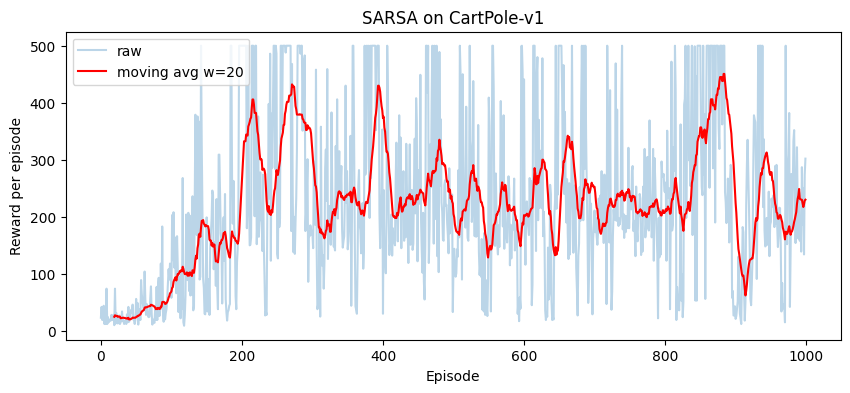

In [31]:
w = 20
plt.figure(figsize=(10, 4))
plt.plot(ep_rewards_sarsa, alpha=0.3, label='raw')
plt.plot(np.arange(w-1, max_ep), moving_average(ep_rewards_sarsa, w),
         color='red', label=f'moving avg w={w}')
plt.xlabel('Episode')
plt.ylabel('Reward per episode')
plt.title('SARSA on CartPole-v1')
plt.legend()
plt.show()

### [Task 3.4.3] Q-learning [Coding, 10 points]

Implement Q_learning algorithm (See Sutton&Barto Section 6.5) on this example for 1000 episodes to to learn the optimal policy.

In [32]:
bins_pos   = []
bins_d_pos = []
bins_ang   = np.linspace(-0.41887903, 0.41887903, 5)
bins_d_ang = np.linspace(-0.87266, 0.87266, 11)

dobs = DiscretObs([bins_pos, bins_d_pos, bins_ang, bins_d_ang])

env = gym.make('CartPole-v1')

n_actions = 2
Q_shape = tuple(dobs._state_num_list) + (n_actions,)
Q_ql_cp = np.zeros(Q_shape)

gamma = 0.98
max_ep = 1000
ep_rewards_ql = np.zeros(max_ep)

for ep in range(max_ep):
    obs, info = env.reset()

    alpha = get_learning_rate(ep)
    epsilon = get_epsilon(ep)

    current_idx = tuple(dobs.obs2state(obs))

    done = False
    total_r = 0
    while not done:
        action = get_action(current_idx, Q_ql_cp, epsilon)

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        total_r += reward
        next_idx = tuple(dobs.obs2state(obs))
        max_action = int(np.argmax(Q_ql_cp[next_idx]))

        Q_ql_cp = update_Q(Q_ql_cp, current_idx, next_idx,
                           action, max_action, alpha, reward, gamma)

        current_idx = next_idx

    ep_rewards_ql[ep] = total_r

env.close()
print("Q-learning done. mean reward (last 100):", ep_rewards_ql[-100:].mean())

Q-learning done. mean reward (last 100): 382.33


### [Task 3.4.3] Coding [5 points]
- Plot the average reward for each episode
- You may (and are encouraged to) also plot the 'windowed' reward (you can use the same function from MonteCarlo method)

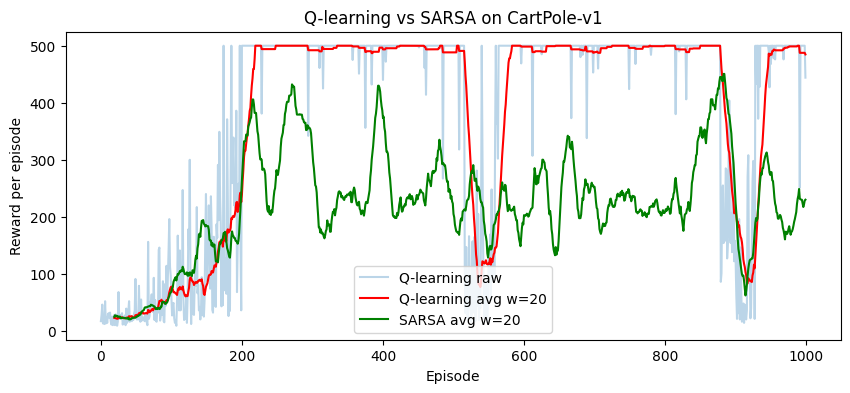

In [33]:
# Q-learning + comparison of reward curves
w = 20
plt.figure(figsize=(10, 4))
plt.plot(ep_rewards_ql, alpha=0.3, label='Q-learning raw')
plt.plot(np.arange(w-1, max_ep), moving_average(ep_rewards_ql, w),
         color='red', label=f'Q-learning avg w={w}')
plt.plot(np.arange(w-1, max_ep), moving_average(ep_rewards_sarsa, w),
         color='green', label=f'SARSA avg w={w}')
plt.xlabel('Episode')
plt.ylabel('Reward per episode')
plt.title('Q-learning vs SARSA on CartPole-v1')
plt.legend()
plt.show()